#第一步先讀取CSV檔來看數據長怎樣

In [1]:
import pandas as pd

data = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',header=None)
data.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num','marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

data.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


#檢查一下資料庫是否有缺失數值

In [2]:
import numpy as np

data = data.replace('?',np.NaN)

print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of missing values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))

Number of instances = 32561
Number of attributes = 15
Number of missing values:
	age: 0
	workclass: 0
	fnlwgt: 0
	education: 0
	education-num: 0
	marital-status: 0
	occupation: 0
	relationship: 0
	race: 0
	sex: 0
	capital-gain: 0
	capital-loss: 0
	hours-per-week: 0
	native-country: 0
	income: 0


#計算各項的平均值,標準差,最大值與最小值

In [3]:
from pandas.api.types import is_numeric_dtype

for col in data.columns:
    if is_numeric_dtype(data[col]):
        print('%s:' % (col))
        print('\t Mean = %.2f' % data[col].mean())
        print('\t Standard deviation = %.2f' % data[col].std())
        print('\t Minimum = %.2f' % data[col].min())
        print('\t Maximum = %.2f' % data[col].max())

age:
	 Mean = 38.58
	 Standard deviation = 13.64
	 Minimum = 17.00
	 Maximum = 90.00
fnlwgt:
	 Mean = 189778.37
	 Standard deviation = 105549.98
	 Minimum = 12285.00
	 Maximum = 1484705.00
education-num:
	 Mean = 10.08
	 Standard deviation = 2.57
	 Minimum = 1.00
	 Maximum = 16.00
capital-gain:
	 Mean = 1077.65
	 Standard deviation = 7385.29
	 Minimum = 0.00
	 Maximum = 99999.00
capital-loss:
	 Mean = 87.30
	 Standard deviation = 402.96
	 Minimum = 0.00
	 Maximum = 4356.00
hours-per-week:
	 Mean = 40.44
	 Standard deviation = 12.35
	 Minimum = 1.00
	 Maximum = 99.00


#計算其各個不同值的頻率

In [4]:
data['income'].value_counts()

income
 <=50K    24720
 >50K      7841
Name: count, dtype: int64

#檢視一下數據裡面有甚麼

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#檢視數據裡面所有的東西,因為上面的info只能看到資料的一部分

In [6]:
data.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


 About Covariance and Correlation
 Covariance的中文為協方差:當協方差為正的時候代表這兩項的變化方向相同,如果是負的話代表他們變化方向相反
 Correlation的中文為相關係數:其數值是在1與-1之間,當相關係數接近1時代表這兩項有正線性關係,當相關係數接近-1時代表這兩項有負線性關係,相關係數為0時代表這兩項沒有線性關係
 

#計算Covariance 

In [7]:
print('Covariance:')
data.cov(numeric_only=True)

Covariance:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,186.061400,-1.103507e+05,1.281849,7.824819e+03,317.560742,11.580130
fnlwgt,-110350.685300,1.114080e+10,-11729.527298,3.366625e+05,-436030.333167,-24460.426185
education-num,1.281849,-1.172953e+04,6.618890,2.330008e+03,82.856445,4.705338
capital-gain,7824.818537,3.366625e+05,2330.007877,5.454254e+07,-94085.760688,7150.032029
capital-loss,317.560742,-4.360303e+05,82.856445,-9.408576e+04,162376.937814,269.953755
hours-per-week,11.580130,-2.446043e+04,4.705338,7.150032e+03,269.953755,152.458995


#計算Correlation #相關係數如果是正的,就是正相關,如果是負的,就是負相關

In [8]:
print('Correlation:')
data.corr(numeric_only=True)


Correlation:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


#提取關於年齡欄位的相關係數並依照大小由上往下排序

In [9]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix["age"].sort_values(ascending=False)

age               1.000000
capital-gain      0.077674
hours-per-week    0.068756
capital-loss      0.057775
education-num     0.036527
fnlwgt           -0.076646
Name: age, dtype: float64

#請系統繪製出"年齡"欄位的直方圖且以8個區間來呈現

<Axes: >

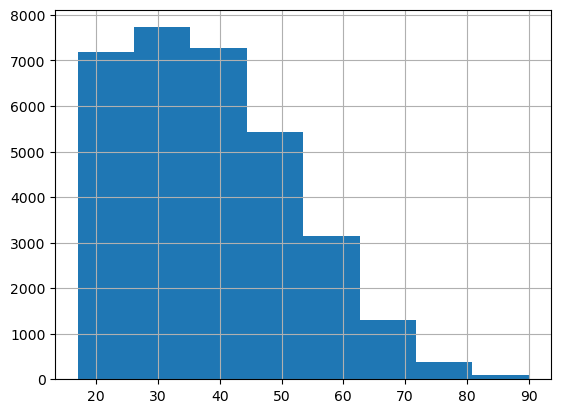

In [10]:
%matplotlib inline

data['age'].hist(bins=8)

透過上圖這張表我們可以得出此數據裡的社會是個中年人(20-40歲的人)居多的社會

#拉出來看一下每個禮拜的上班總時數

<Axes: >

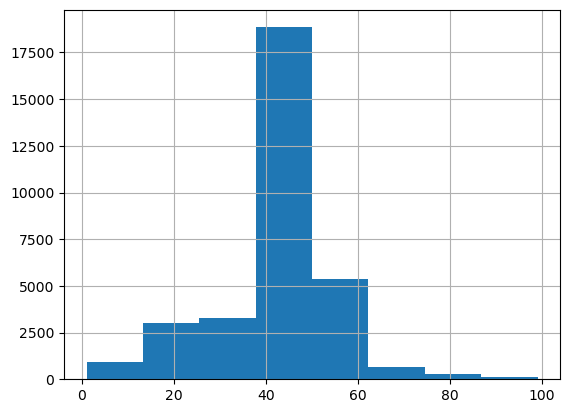

In [18]:
%matplotlib inline

data['hours-per-week'].hist(bins=8)

根據上方這張圖可以看出大部分人的總工作時數是落在39-50小時,以周休二日來看的話一天他們的工作時長落在7.8-10小時

#拉出來看一下他們平均受過幾年的教育

<Axes: >

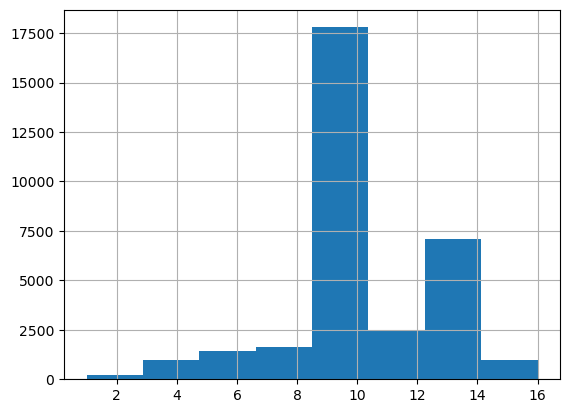

In [20]:
%matplotlib inline

data['education-num'].hist(bins=8)

根據上圖的圖表可以得知多數人大概受過8-10年的教育,可以推斷大部分人在高中畢業時就出去就業了

#請系統繪製出所有欄位的直方圖並以8個區間來呈現

In [11]:
import os

IMAGES_PATH = '.'

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Saving figure attribute_histogram_plots


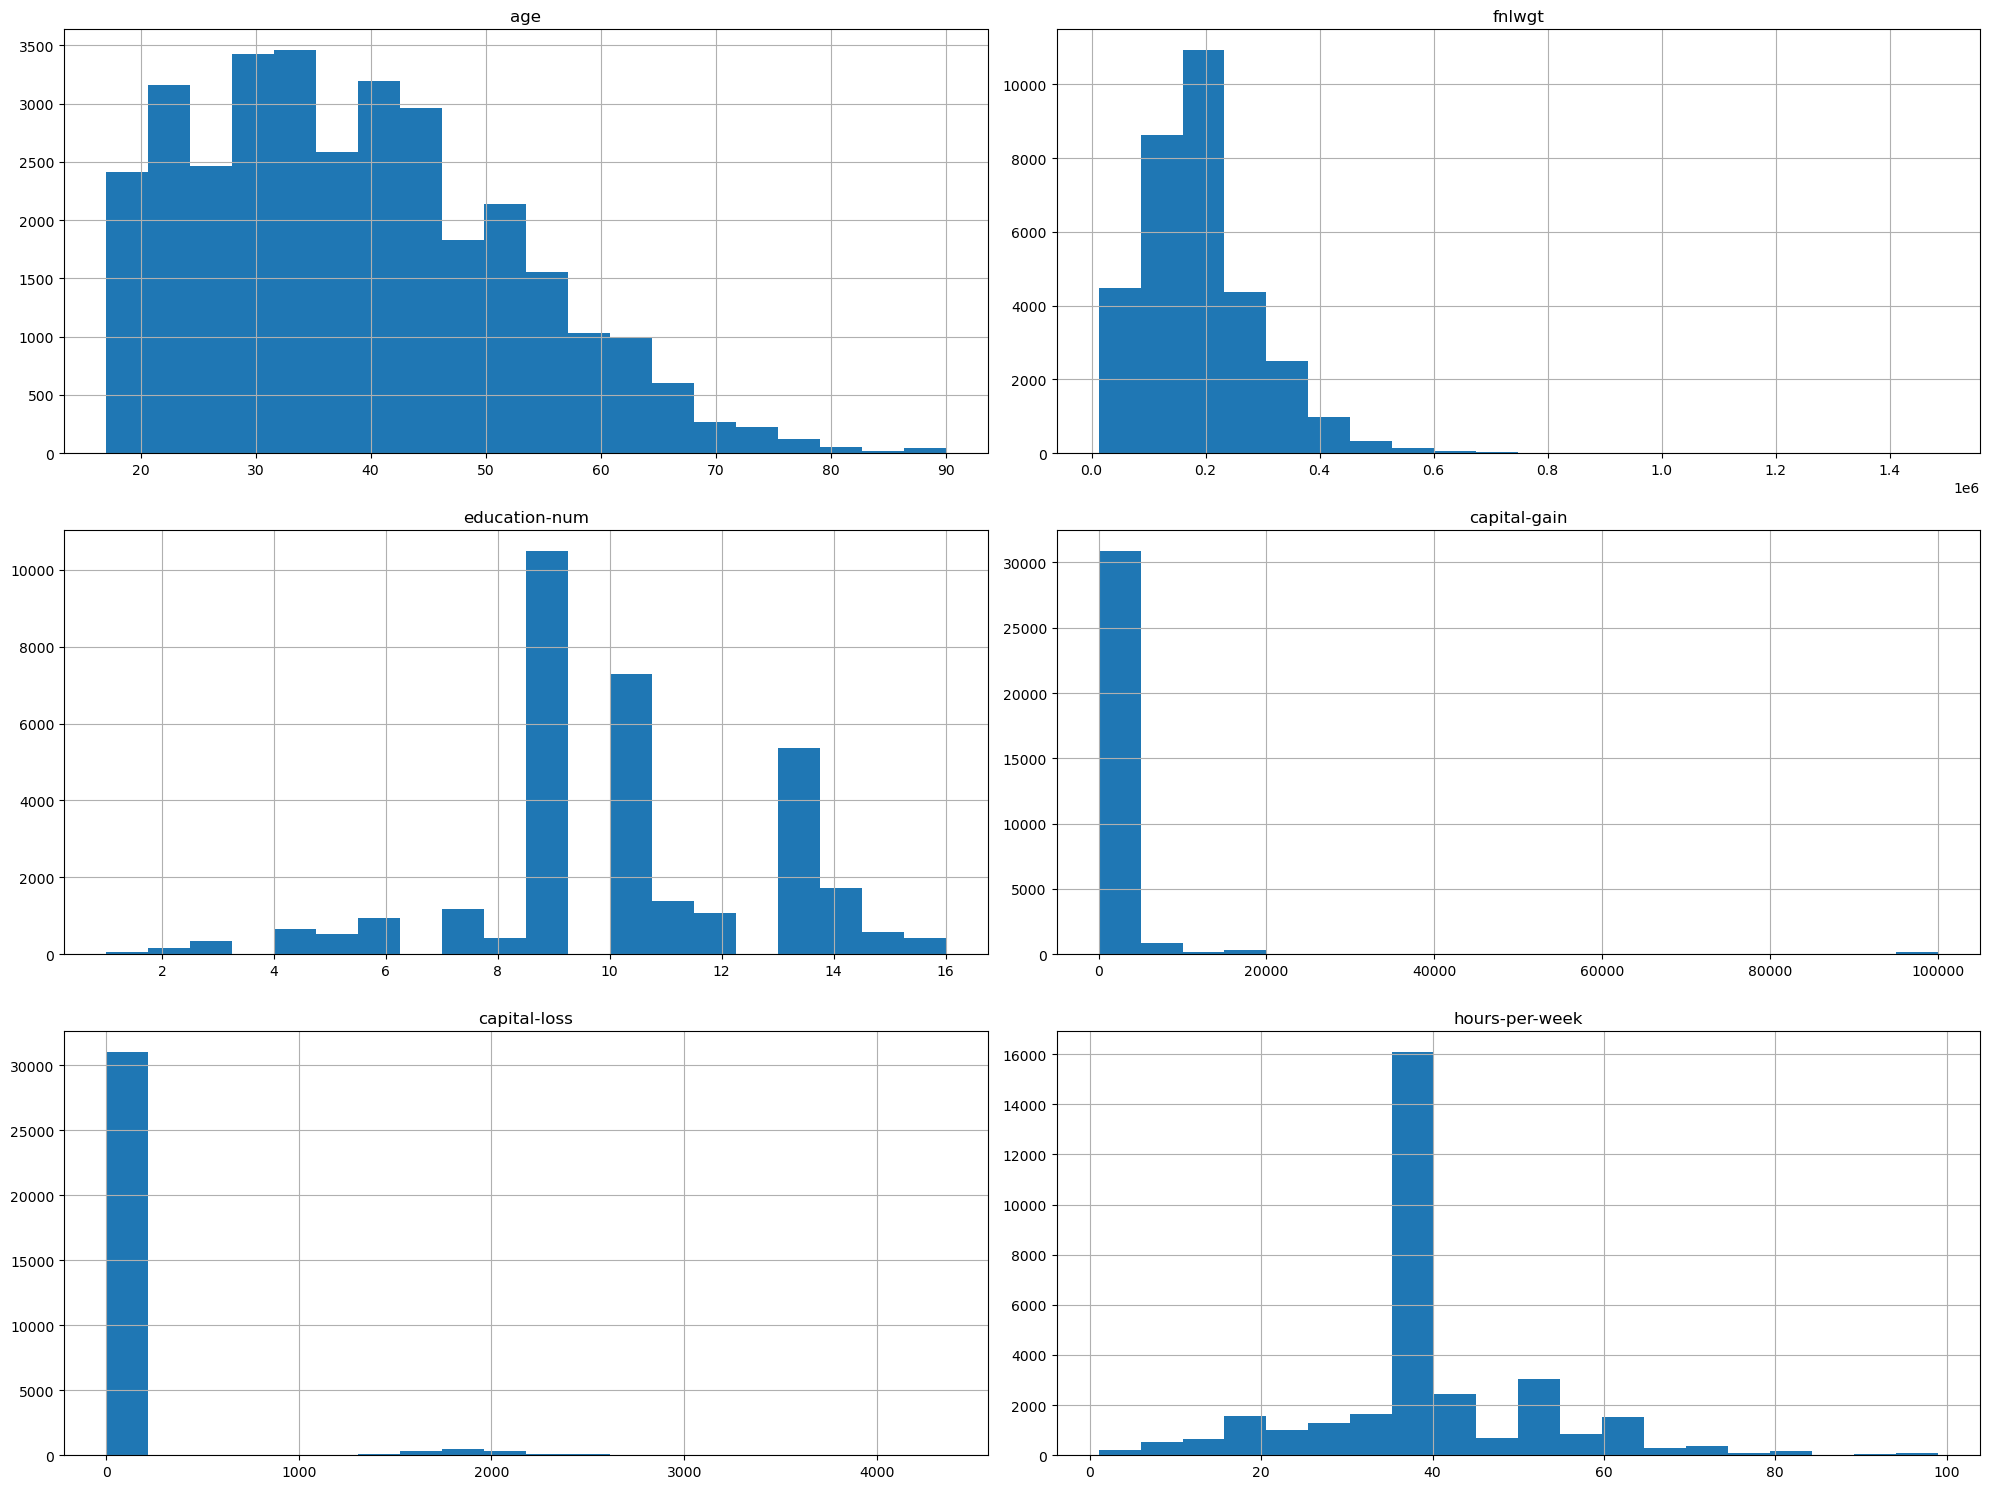

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
data.hist(bins=20, figsize=(20,15))
save_fig("attribute_histogram_plots")
plt.show()

#請系統跑盒形圖,如果有看不清或是想單獨拆開來看的東西的話就在括號裡面加你想看的項目即可)

<Axes: >

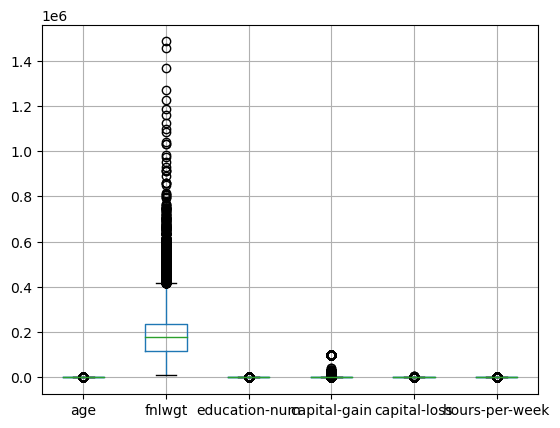

In [13]:
data.boxplot()

#指定系統繪製出6個散布圖(一行2個,共3行)去從圖中理解出特徵之間的關係

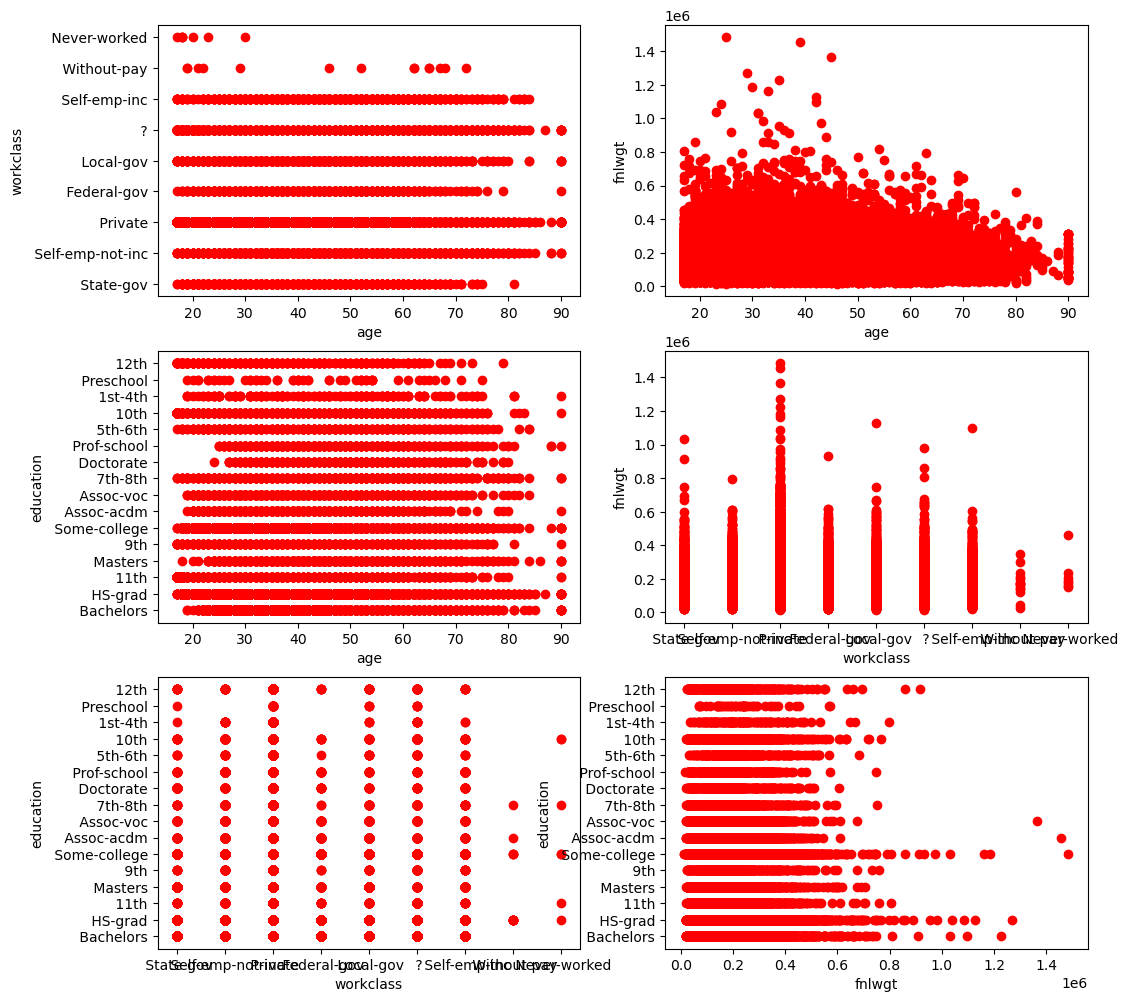

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12,12))
index = 0
for i in range(3):
    for j in range(i+1,4):
        ax1 = int(index/2)
        ax2 = index % 2
        axes[ax1][ax2].scatter(data[data.columns[i]], data[data.columns[j]], color='red')
        axes[ax1][ax2].set_xlabel(data.columns[i])
        axes[ax1][ax2].set_ylabel(data.columns[j])
        index = index + 1

#請系統畫散布圖矩陣,只是這種圖會比上方的散布圖還要簡潔

Saving figure scatter_matrix_plot


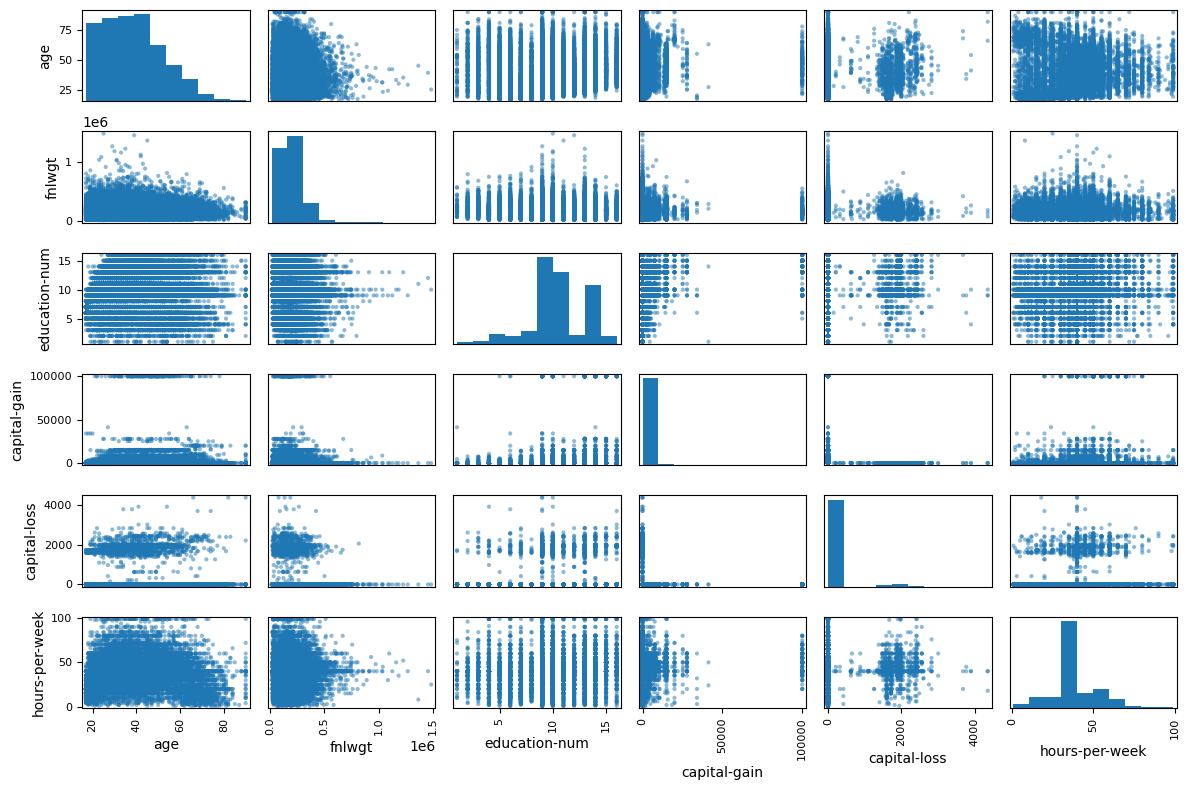

In [16]:
from pandas.plotting import scatter_matrix
scatter_matrix(data, figsize=(12, 8))
save_fig("scatter_matrix_plot")

總結:
1.這次的數據資料庫是拿欄位是數字的進行分析
2.首先先引進資料庫並確認引進的資料有沒有數值缺失,沒有數值缺失的話就可以去測各項的平均,標準差,最大值與最小值
3.測試完Covariance跟Correlation後會發現大部分的數據是有關聯的
4.透過數據視覺化我們可以得知此數據呈現的是一個中年人(20-40歲的人)居多的社會,且他們讀了8-10年的書後就出去工作了,他們工時是落在一天7.8-10小時(這邊是指周休二日情況下)
這些技術對於檢查資料與分析及預測非常有幫助